## Overview

This notebook builds a synthetic multi-asset portfolio with known ground truth. The point is to have something where I know the "true" underlying price dynamics, so later I can check whether the Kalman filter and HMM are actually recovering that signal before testing them on real financial data.

Four correlated assets, each with its own drift and volatility:

- EQTY, generic equity
- BOND, fixed income
- GOLD, safe haven commodity
- TECH, higher growth, higher volatility

In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("../src")

from simulate_gbm_market import simulate_gbm_market

In [20]:
from dataclasses import dataclass

# Creating a struct because I can
@dataclass
class Asset:
    ticker: str
    mu: float
    sigma: float

# Definition of assets
# mu being expected returns and sigma being volatility
assets = [
    Asset("EQTY", mu=0.07, sigma=0.18),
    Asset("BOND", mu=0.03, sigma=0.05),
    Asset("GOLD", mu=0.02, sigma=0.15),
    Asset("TECH", mu=0.12, sigma=0.35),
]

# We create a correlation matrix, as a standard equity portfolio will have significant overlap with tech    
corr = np.array([
    [1.00,  -0.30, 0.05, 0.55],
    [-0.30,  1.00, 0.10, -0.25],
    [0.05,   0.10, 1.00, 0.00],
    [0.55,  -0.25, 0.00, 1.00],
])

# We create starting values for our simulation, indexing everything to 100
s0 = np.array([100, 100, 100, 100])

Now that we have initial conditions set up we create a function that let's us simulate a market using brownian motion
Having done some research I know the best way to make them correlate with eachother is to go take a second look on cholesky decompositions

In [24]:
# Simulates correlated geometric Brownian Motion for N assets.
# Each asset gets assigned a drift and a volatility
# Correlation imposed using cholesky

# Run it
prices = simulate_gbm_market(assets, corr, s0, n_days=1000, seed=None)
prices.head()

NameError: name 'np' is not defined

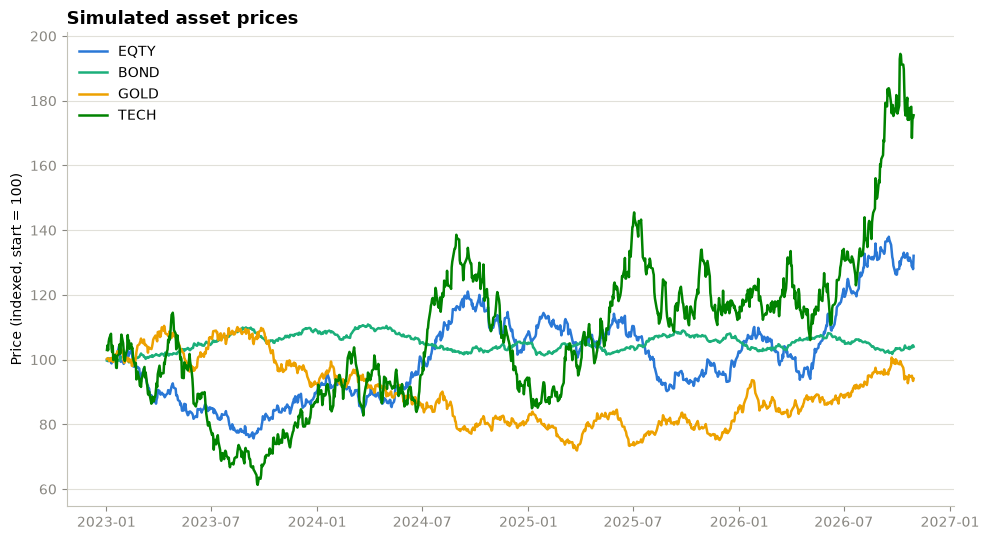

In [23]:
COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(prices.columns, COLORS):
    ax.plot(prices.index, prices[ticker], color=color, linewidth=1.8, label=ticker)

ax.set_title("Simulated asset prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

**We now have a reliable way to simulate the markets from from our known outputs**
The next step is to make a Kalman filter to retrive the underlying data

**Because we know the actual underlying characteristics of this data, we can use it to tune the parameters of our Kalman filter**, we just have to be careful not to overfit the data.